# Tree Structure vs. Train/Test Accuracy

You cannot hand-edit a fitted SGT node by node — the fitted tree is read-only (see [Inspecting trees](inspecting-trees.ipynb); the only in-place editor is [TAO](tao.ipynb)). The lever you *do* control is **structure via hyperparameters**. This notebook sweeps the main structural knobs and watches training and test accuracy move — the practical way to tune an SGT.

## Setup

Breast-cancer (30 features, binary) is rich enough that structure changes actually move accuracy. We disable TAO (`tao_n_runs=0`) so we measure the *structure's* effect, not refinement.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sgtlearn import SGTClassifier

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

def curve(param, values, **fixed):
    tr, te = [], []
    for v in values:
        m = SGTClassifier(tao_n_runs=0, random_state=0, **{param: v}, **fixed).fit(X_tr, y_tr)
        tr.append(m.score(X_tr, y_tr)); te.append(m.score(X_te, y_te))
    return tr, te

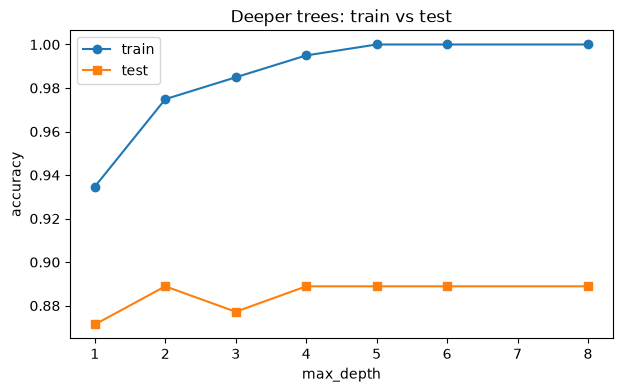

max_depth=1: train=0.935 test=0.871
max_depth=2: train=0.975 test=0.889
max_depth=3: train=0.985 test=0.877
max_depth=4: train=0.995 test=0.889
max_depth=5: train=1.000 test=0.889
max_depth=6: train=1.000 test=0.889
max_depth=8: train=1.000 test=0.889


In [2]:
depths = [1, 2, 3, 4, 5, 6, 8]
tr, te = curve("max_depth", depths)
plt.figure(figsize=(7, 4))
plt.plot(depths, tr, "o-", label="train")
plt.plot(depths, te, "s-", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.title("Deeper trees: train vs test")
plt.show()
for d, a, b in zip(depths, tr, te):
    print(f"max_depth={d}: train={a:.3f} test={b:.3f}")

## What to notice — over/underfitting

Training accuracy climbs monotonically with `max_depth` (more capacity always fits the training data better). Test accuracy climbs, then flattens or dips — the classic bias/variance turn. The best `max_depth` is where the **test** curve peaks, not the train curve.

In [3]:
# inner_max_depth — richer per-node shape functions.
inners = [1, 2, 3, 4]
tr, te = curve("inner_max_depth", inners, max_depth=3)
for d, a, b in zip(inners, tr, te):
    print(f"inner_max_depth={d}: train={a:.3f} test={b:.3f}")

inner_max_depth=1: train=0.967 test=0.936
inner_max_depth=2: train=0.972 test=0.895
inner_max_depth=3: train=0.985 test=0.877
inner_max_depth=4: train=0.987 test=0.871


In [4]:
# min_samples_leaf — a regularizer: larger values forbid tiny leaves, reducing overfit.
leafs = [1, 5, 20, 50]
tr, te = curve("min_samples_leaf", leafs, max_depth=6)
for n, a, b in zip(leafs, tr, te):
    print(f"min_samples_leaf={n}: train={a:.3f} test={b:.3f}")

min_samples_leaf=1: train=1.000 test=0.889
min_samples_leaf=5: train=0.982 test=0.877
min_samples_leaf=20: train=0.950 test=0.930
min_samples_leaf=50: train=0.935 test=0.871


## Takeaways

- `max_depth` and `inner_max_depth` add capacity — raise them until the **test** score stops improving.
- `min_samples_leaf` removes capacity — raise it to fight overfitting (train drops; test moves non-monotonically here, so pick the value that maximizes the test score rather than assuming larger is always better).
- `pairwise_candidates` expands interaction search and `pairwise_penalty` discourages pair selection; see [S²GT bivariate branching](bivariate-branching.ipynb).
- Once structure is chosen, [TAO](tao.ipynb) refines the rules inside that fixed structure.